# Portfolio Construction & Metrics

Loads cleaned prices, computes log returns, builds the equal-weight baseline portfolio, reports annualized return / volatility / Sharpe, and — the new addition — shows a rolling 30-day correlation view that demonstrates correlations are *not* static (a key limitation of parametric VaR).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load prices and compute log returns
prices = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
log_returns = np.log(prices / prices.shift(1)).dropna()

tickers = list(prices.columns)
n_assets = len(tickers)
weights = np.array([1 / n_assets] * n_assets)
assert abs(weights.sum() - 1.0) < 1e-9

portfolio_returns = log_returns.dot(weights)
print(f"Loaded {len(prices)} trading days across {n_assets} assets: {tickers}")

Loaded 1509 trading days across 8 assets: ['AAPL', 'BRK-B', 'GLD', 'GOOGL', 'JPM', 'MSFT', 'SPY', 'TLT']


## Annualized portfolio metrics

In [2]:
cov_matrix = log_returns.cov() * 252

portfolio_variance   = weights.T @ cov_matrix @ weights
portfolio_volatility = np.sqrt(portfolio_variance)

annual_asset_returns = log_returns.mean() * 252
portfolio_return     = annual_asset_returns.dot(weights)

risk_free_rate = 0.045
sharpe_ratio   = (portfolio_return - risk_free_rate) / portfolio_volatility

print("--- Equal-weight portfolio (annualized) ---")
print(f"Expected return: {portfolio_return:.2%}")
print(f"Volatility:      {portfolio_volatility:.2%}")
print(f"Sharpe ratio:    {sharpe_ratio:.3f}")

--- Equal-weight portfolio (annualized) ---
Expected return: 16.71%
Volatility:      16.83%
Sharpe ratio:    0.725


## Cumulative growth of $1 by asset

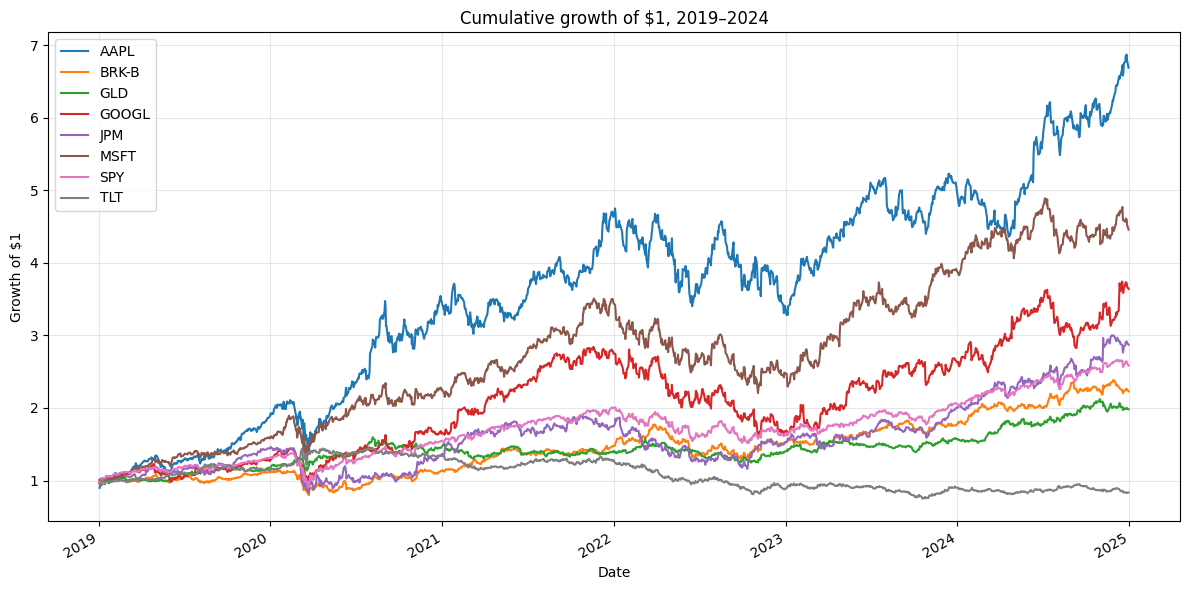

In [3]:
cum_returns = np.exp(log_returns.cumsum())

fig, ax = plt.subplots(figsize=(12, 6))
cum_returns.plot(ax=ax)
ax.set_title("Cumulative growth of $1, 2019–2024")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Full-period correlation matrix

A single snapshot across the whole 2019–2024 window.

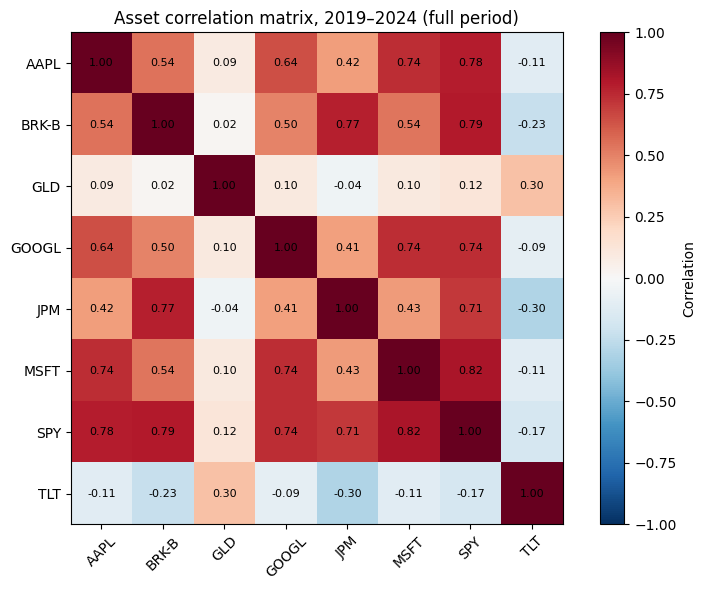

In [4]:
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(im, label="Correlation")
ax.set_xticks(range(n_assets)); ax.set_xticklabels(tickers, rotation=45)
ax.set_yticks(range(n_assets)); ax.set_yticklabels(tickers)

# Annotate with the correlation values
for i in range(n_assets):
    for j in range(n_assets):
        ax.text(j, i, f"{corr.iat[i,j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Asset correlation matrix, 2019–2024 (full period)")
plt.tight_layout()
plt.show()

## Rolling 30-day correlation — correlations are not static

The static matrix above hides regime changes. For a few revealing pairs, plot a 30-day rolling correlation over the full window. This is the visual justification for why parametric VaR — which treats the covariance matrix as fixed — is limited.

Pairs to watch:
- **SPY-TLT**: classic 'stocks vs bonds' — usually negative, but flipped positive in 2022 when rate hikes hit both at once
- **SPY-GLD**: gold's diversification value is highly regime-dependent
- **AAPL-MSFT**: intra-sector correlation — nearly always high, but the *level* varies

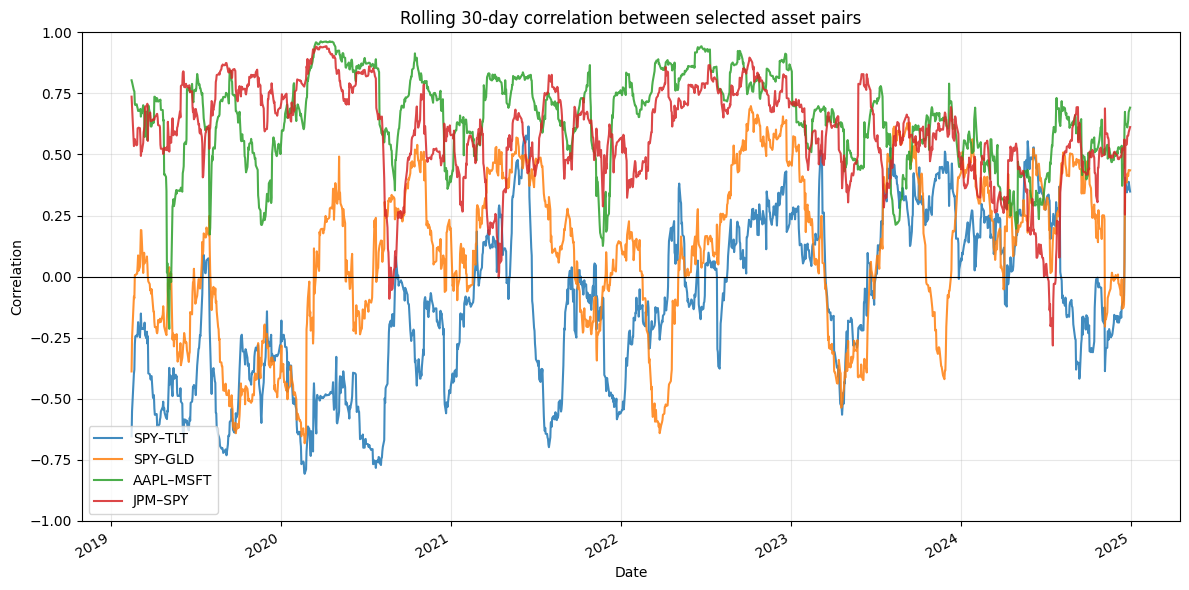

Range of rolling correlations:
     SPY–TLT  SPY–GLD  AAPL–MSFT  JPM–SPY
min   -0.807   -0.682     -0.213   -0.282
max    0.615    0.698      0.963    0.943


In [5]:
window = 30
pairs = [("SPY", "TLT"), ("SPY", "GLD"), ("AAPL", "MSFT"), ("JPM", "SPY")]

rolling = pd.DataFrame(index=log_returns.index)
for a, b in pairs:
    rolling[f"{a}–{b}"] = log_returns[a].rolling(window).corr(log_returns[b])
rolling = rolling.dropna()

fig, ax = plt.subplots(figsize=(12, 6))
rolling.plot(ax=ax, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Rolling {window}-day correlation between selected asset pairs")
ax.set_ylabel("Correlation")
ax.set_ylim(-1, 1)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("Range of rolling correlations:")
print(rolling.agg(['min', 'max']).round(3))

**Reading this chart for your report:** the SPY-TLT line is the headline. It sits deeply negative through 2019–2021 (the standard 'bonds hedge stocks' regime), then crosses into positive territory during 2022 as aggressive rate hikes hurt both asset classes simultaneously. This is exactly the kind of correlation breakdown that a static covariance matrix — and therefore parametric VaR — cannot capture.

## Save for downstream notebooks

In [6]:
log_returns.to_csv("../data/log_returns.csv")
portfolio_returns.to_csv("../data/portfolio_returns.csv")
print("Saved ../data/log_returns.csv and ../data/portfolio_returns.csv")

Saved ../data/log_returns.csv and ../data/portfolio_returns.csv
